# Tutorial 4: Image Generation (Diffusion Models)

Building on our previous study of VAEs and GANs, this tutorial introduces **Diffusion Models**, the current state-of-the-art framework for high-quality image synthesis. We will first examine the core **principles** of the diffusion process, where the model learns to systematically remove noise from data, and introduce modern concepts like **Flow Matching**. The second part focuses on **controllable generation** and efficiency, guiding you through the architecture of **Latent Diffusion Models** and techniques like **Classifier-Free Guidance** to generate specific images.

> This tutorial is referenced from the following papers and blogs:
> - https://arxiv.org/abs/2510.21890
> - https://arxiv.org/abs/2410.11081
> - https://arxiv.org/abs/2305.08891
> - https://arxiv.org/abs/2011.13456
> - https://arxiv.org/abs/1907.05600
> - https://yang-song.net/blog/2021/score/

## Part 1: Principles of Diffusion Models

We will start by defining the **Formulation of the Diffusion Process** and exploring the **Training Dynamics** required for the model to effectively learn how to reverse noise. Following this, we will examine various **Generative Sampling** methods used to synthesize data and conclude by introducing the unified perspective of **Flow Matching**.

### **1.1 Formulation of Diffusion Process**

#### **1.1.1 Forward Process & Noise Schedule**

The core concept of diffusion models comes from **thermodynamics**. We use this approach because real-world data lies on a complex **high-dimensional manifold** where valid points are sparse. By adding noise, we expand the distribution to cover the whole space. We describe this **forward process** mathematically using a **Stochastic Differential Equation (SDE)**. The general form is written as:
$$d\mathbf{x} = \mathbf{f}(\mathbf{x}, t)dt + g(t)d\mathbf{w}$$
In this equation, $\mathbf{f}(\mathbf{x}, t)$ is the **drift coefficient** which controls the deterministic path, and $g(t)$ is the **diffusion coefficient**. The term $d\mathbf{w}$ represents **Brownian motion**. You can understand this as a continuous accumulation of random shocks, where the change in any small step follows a **standard Gaussian distribution**.

The specific choice of these terms is called the **noise schedule**. It is important to note that this schedule is **hand-crafted**, meaning we manually design how the data is corrupted. While the SDE describes a process that is continuous in time, famous models like **DDPM** are essentially discretizations of a specific hand-crafted SDE. However, modern approaches often model the process in continuous time directly for better flexibility.

Technically, the SDE describes how data changes over an **infinitesimal time interval**. However, for practical implementation, we always design the noise schedule to set the transition kernel as **Gaussian distribution**. This means we can calculate the noisy state at any time $t$ directly from the start through a **closed-form solution**, without simulating every small step. This transition is usually written as:
$$\mathbf{x}_t = \alpha_t \mathbf{x}_0 + \sigma_t \epsilon$$
Here, $\mathbf{x}_0$ is the clean input and $\epsilon$ is the **Gaussian noise**. The parameters **$\alpha_t$** and **$\sigma_t$** determine the signal and noise levels and are derived from the SDE definition.

In [ ]:
import numpy as np

# Demo of Variance Preserving (VP) noise schedule in Stable Diffusion (based on DDPM discretization)
# SDE: dx = f(x,t) dt + g(t) dw
# For VP: f(x,t) = -0.5 * beta(t) * x  (drift pulls towards origin)
#         g(t)   = sqrt(beta(t))        (diffusion adds noise)
# This leads to closed-form: x_t = alpha_t * x_0 + sigma_t * epsilon (epsilon ~ N(0,I))
# Where alpha_t = sqrt(alpha_bar_t), sigma_t = sqrt(1 - alpha_bar_t)
# alpha_bar_t = product from i=1 to t of (1 - beta_i)  (signal retention)
# beta(t) is hand-crafted linear schedule; larger t means smaller alpha_t, larger sigma_t (more noise)

# Classic Stable Diffusion params: linear betas over T=1000 steps
T = 1000
beta_start = 0.0001
beta_end = 0.02
betas = np.linspace(beta_start, beta_end, T)  # beta(t) increases with t

# Compute cumulative products for alpha_bar
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas, axis=0)  # alpha_bar_t = prod_{i=1}^t alphas_i

# Print for some timesteps (t starts from 1; larger t = more noise)
for t in [1, 250, 500, 750, 1000]:
    alpha_bar_t = alpha_bars[t-1]  # 0-indexed
    alpha_t = np.sqrt(alpha_bar_t)
    sigma_t = np.sqrt(1 - alpha_bar_t)
    print(f"t={t}: alpha_t={alpha_t:.4f} (signal), sigma_t={sigma_t:.4f} (noise)")

# Actual noising demo: add noise to a simple x_0 vector
np.random.seed(42)  # For reproducibility
x_0 = np.array([1.0, 2.0, 3.0])  # Clean input (e.g., simplified "image")
print("\nClean x_0:", x_0)

# Noise at specific t (e.g., t=500)
t = 500
alpha_bar_t = alpha_bars[t-1]
alpha_t = np.sqrt(alpha_bar_t)
sigma_t = np.sqrt(1 - alpha_bar_t)
epsilon = np.random.randn(*x_0.shape)  # Gaussian noise ~ N(0,1)
x_t = alpha_t * x_0 + sigma_t * epsilon
print(f"Noisy x_t at t={t}:", x_t)


t=1: alpha_t=0.9999 (signal), sigma_t=0.0100 (noise)
t=250: alpha_t=0.7239 (signal), sigma_t=0.6899 (noise)
t=500: alpha_t=0.2803 (signal), sigma_t=0.9599 (noise)
t=750: alpha_t=0.0579 (signal), sigma_t=0.9983 (noise)
t=1000: alpha_t=0.0064 (signal), sigma_t=1.0000 (noise)

Clean x_0: [1. 2. 3.]
Noisy x_t at t=500: [0.75713131 0.42794808 1.46272032]


#### **1.1.2 Reverse Process & Parameterization**

To generate new samples, we must reverse the diffusion process. Mathematical theory guarantees that for any forward SDE, there exists a corresponding reverse SDE:
$$d\mathbf{x} = [f(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d\bar{\mathbf{w}}$$
In this equation, $f$ and $g$ are known terms derived from the forward process.
The only unknown term here $\nabla_\mathbf{x} \log p_t(\mathbf{x})$ represents the gradient of the log-probability density of the noisy data. We call this the **Score**. Intuitively, the Score is a vector field that points towards regions of high data density.

Calculating this score directly is impossible because the true marginal distribution $p_t(\mathbf{x})$ is unknown. However, thanks to the noise schedule, we can easily compute the **score of the conditional distribution** $\nabla \log p(x_t|x_0)$, which is proportional to the added noise. We can then parameterize a **deep neural network** and use this score value to supervise the network.
This training method is known as **Denoising Score Matching (DSM)**. With sufficient data and model capacity, DSM guarantees that training a network to match this simple conditional score is equivalent to learning the score of the true marginal distribution.

Once we have successfully trained this score network, we can plug it into the reverse equation to replace the unknown term. Consequently, the most straightforward way to generate data is to simply **simulate and discretize** this reverse SDE starting from pure noise. By following the trajectory defined by the equation, the noise evolves back into a data sample. While this is the standard approach, there are alternative sampling methods, which we will discuss in the upcoming sections.

In [ ]:
import numpy as np

# Reuse params from previous step
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

# ------------------------------------------------------------------
# 1. Mock Neural Network (The "Score Network")
# ------------------------------------------------------------------
# In reality, this is a trained U-Net.
# Input: Noisy x_t and time t. Output: Predicted noise epsilon.
def unet_predict_noise(x_t, t_index):
    # Just returning random noise for demo purposes
    return np.random.randn(*x_t.shape)

# ------------------------------------------------------------------
# 2. Reverse Step Simulation (t -> t-1)
# ------------------------------------------------------------------
# Let's assume we are at step t=500 with a noisy image x_t
t = 500
t_idx = t - 1
x_t = np.random.randn(3) # Represents a noisy latent vector

# Get parameters for this step
beta_t = betas[t_idx]
alpha_t = alphas[t_idx]
alpha_bar_t = alpha_bars[t_idx]
sigma_t = np.sqrt(1 - alpha_bar_t) # Total noise std dev at time t

# A. Network Prediction
eps_pred = unet_predict_noise(x_t, t_idx)

# B. Calculate Score (The "Unknown Term" in SDE)
# Math: Score = Gradient of log density
# Connection: Score ≈ -epsilon_pred / sigma_t
# Interpretation: The vector pointing towards higher data density
estimated_score = -eps_pred / sigma_t
print(f"Predicted Noise: {eps_pred}")
print(f"Estimated Score: {estimated_score} (Points to clean data)")

# C. Discretize Reverse SDE (The "Solver")
# SDE: dx = [ f(x,t) - g(t)^2 * Score ] dt + ...
#
# Mapping to code:
# 1. f(x,t) term: Represented by the 1/sqrt(alpha_t) scaling (reverses the drift).
# 2. -g(t)^2 * Score term: This is the "Denoising Force".
#    Since g(t)^2 = beta_t and Score ~ -eps/sigma, this term becomes positive.
#    In code, we subtract the noise (eps_pred), which is equivalent to adding the score.

# Standard DDPM update step (simplified):
# x_{t-1} = (1/sqrt(alpha_t)) * (x_t - coeff * eps_pred) + sigma * z
coeff = beta_t / np.sqrt(1 - alpha_bar_t)
z = np.random.randn(*x_t.shape) if t > 1 else 0

x_prev = (1 / np.sqrt(alpha_t)) * (x_t - coeff * eps_pred) + np.sqrt(beta_t) * z

print(f"x_t (Noisy): {x_t}")
print(f"x_{{t-1}} (Denoised): {x_prev}")


Predicted Noise: [ 1.57921282  0.76743473 -0.46947439]
Estimated Score: [-1.64518048 -0.7994924   0.48908551] (Points to clean data)
x_t (Noisy): [ 1.52302986 -0.23415337 -0.23413696]
x_{t-1} (Denoised): [ 1.56849684 -0.28983975 -0.2770521 ]


### **1.2 Training Dynamics**

#### **1.2.1 Timestep Distribution**

Our score network needs to operate across the entire diffusion timeline, from a clean image to pure noise. This means the network must be **time-conditional**, taking both the noisy image $\mathbf{x}_t$ and the timestep $t$ as input. During each training step, for every clean image in our batch, we must select a random timestep $t$ to corrupt it. The strategy we use to select these timesteps is known as the **timestep distribution**.

The most straightforward approach is to sample timesteps from a **uniform distribution**. This means that every possible noise level, from very small to very large, has an equal chance of being chosen during training. This method is simple to implement and ensures that the model sees examples from the entire range of the diffusion process.

However, a uniform distribution is not always optimal. The difficulty of the denoising task is not the same at all timesteps. For example, removing a tiny amount of noise or predicting the score for a nearly pure noise image can be much easier than handling an image where the signal and noise are heavily mixed. To address this, many modern approaches use a **non-uniform distribution**. This allows us to sample more frequently from timesteps that are more informative or challenging for the model. This strategy helps to **balance the training objective**, ensuring the model performs well across all stages of the reverse process.

The choice of this distribution is closely related to the **training data**. A straightforward implication is that video data exhibits higher redundancy compared to image data, since adjacent frames are generally quite similar, thus timesteps with higher noise intensity require more training time.

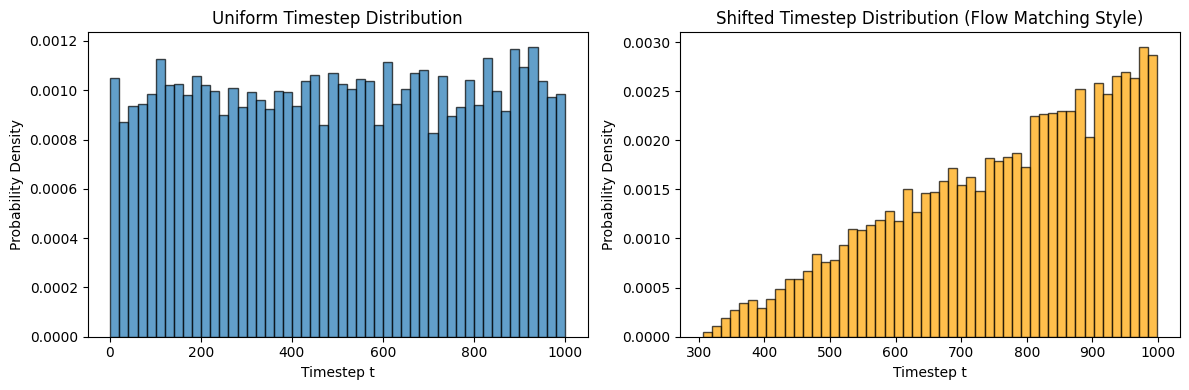


--- Training Step Demo ---
Sampled timesteps for batch: [469 778 994 842]
Sample 1: t=469, sigma_t=0.945, x_0=[ 0.81802314 -0.09935629  2.31028279], x_t=[ 0.63799922 -1.35920635 -1.31907602]
Sample 2: t=778, sigma_t=0.999, x_0=[-0.37294565  0.97712231 -0.38790191], x_t=[ 0.06388892 -0.10966323 -0.25783296]
Sample 3: t=994, sigma_t=1.000, x_0=[ 1.9192164   0.73071431 -1.28528511], x_t=[ 0.59250337 -0.74019529  0.67856652]
Sample 4: t=842, sigma_t=1.000, x_0=[ 1.4070579   0.77524625 -0.467205  ], x_t=[ 0.73314656 -2.63815818 -0.08154603]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Timestep Distribution for Training
# ------------------------------------------------------------------
# During training, for each clean image x_0, we randomly sample a timestep t
# to create x_t = alpha_t * x_0 + sigma_t * epsilon, then train the network.
# The choice of how we sample t is called the "timestep distribution".

T = 1000  # Total timesteps

# ------------------------------------------------------------------
# Strategy 1: Uniform Distribution (Classic DDPM)
# ------------------------------------------------------------------
# Every timestep has equal probability. Simple but may not be optimal.
def sample_uniform_timesteps(batch_size, T):
    return np.random.randint(1, T + 1, size=batch_size)

# Demo: Sample 10000 timesteps and visualize
uniform_samples = sample_uniform_timesteps(10000, T)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=50, density=True, alpha=0.7, edgecolor='black')
plt.title("Uniform Timestep Distribution")
plt.xlabel("Timestep t")
plt.ylabel("Probability Density")

# ------------------------------------------------------------------
# Strategy 2: Biased Distribution (Flow Matching Style with Shift)
# ------------------------------------------------------------------
# Modern approach: Sample more from challenging timesteps (middle-to-high noise).
# Inspired by Flow Matching, we use a "shifted" distribution that puts more
# weight on higher noise levels (larger t).
#
# Implementation: Sample from a Beta distribution then shift towards high t.
# Parameters: alpha, beta control the shape; shift controls the bias.

def sample_shifted_timesteps(batch_size, T, alpha=2, beta=1, shift=0.3):
    # Sample from Beta(alpha, beta), which gives values in [0, 1]
    u = np.random.beta(alpha, beta, size=batch_size)

    # Apply shift: bias towards higher values (more noise)
    # shift ∈ [0, 1]: larger shift = more samples at high t
    u_shifted = u * (1 - shift) + shift

    # Map to timestep range [1, T]
    t = np.clip(u_shifted * T, 1, T).astype(int)
    return t

# Demo: Sample with shift
shifted_samples = sample_shifted_timesteps(10000, T, alpha=2, beta=1, shift=0.3)
plt.subplot(1, 2, 2)
plt.hist(shifted_samples, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
plt.title("Shifted Timestep Distribution (Flow Matching Style)")
plt.xlabel("Timestep t")
plt.ylabel("Probability Density")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Training Loop Example
# ------------------------------------------------------------------
print("\n--- Training Step Demo ---")
batch_size = 4
x_0_batch = np.random.randn(batch_size, 3)  # Mock clean images (batch of 4, dim=3)

# Sample timesteps for this batch (using shifted distribution)
t_batch = sample_shifted_timesteps(batch_size, T, shift=0.3)
print(f"Sampled timesteps for batch: {t_batch}")

# For each sample, add noise according to its timestep
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

for i in range(batch_size):
    x_0 = x_0_batch[i]
    t = t_batch[i]

    # Get noise schedule params for this t
    alpha_bar_t = alpha_bars[t - 1]
    alpha_t = np.sqrt(alpha_bar_t)
    sigma_t = np.sqrt(1 - alpha_bar_t)

    # Add noise: x_t = alpha_t * x_0 + sigma_t * epsilon
    epsilon = np.random.randn(*x_0.shape)
    x_t = alpha_t * x_0 + sigma_t * epsilon

    print(f"Sample {i+1}: t={t}, sigma_t={sigma_t:.3f}, x_0={x_0}, x_t={x_t}")

    # In real training, we would now:
    # 1. Feed (x_t, t) into the network
    # 2. Network predicts epsilon_pred
    # 3. Compute loss: ||epsilon - epsilon_pred||^2
    # 4. Backpropagate and update weights


#### **1.2.2 Loss Weighting & Objective**

Although the theory is based on score matching, we do not always require the network to predict the score directly. Recall the transition equation $\mathbf{x}_t = \alpha_t \mathbf{x}_0 + \sigma_t \epsilon$. Since $\mathbf{x}_t$ is the input to the network and the coefficients are known constants, these target variables are **mathematically convertible**. Predicting one allows us to calculate the others. Therefore, we can choose to parameterize the network to predict the **noise** $\epsilon$, the **clean data** $\mathbf{x}_0$, or even a combination of both known as **velocity** $\mathbf{v}$.

Regardless of what the network predicts, the training objective can always be analyzed as a weighted **Denoising Score Matching (DSM)** loss. The general form is written as:
$$ L = \mathbb{E}_{t, \mathbf{x}_0, \epsilon} \left[ \lambda(t) \| \mathbf{s}_\theta(\mathbf{x}_t, t) - \nabla \log p(\mathbf{x}_t | \mathbf{x}_0) \|^2 \right] $$
Here, $\mathbf{s}_\theta$ is the score estimated by our model, and the term $\lambda(t)$ represents a **time-dependent weighting function**. This weight determines how much importance we assign to the error at each specific noise level.

When we change the parameterization, such as predicting the noise $\epsilon$ (as done in **DDPM**), the relationship between the network output and the score introduces additional coefficients into the loss equation. A common practical strategy is to set $\lambda(t)$ to the **inverse** of these coefficients. By doing this, the complex terms cancel out, and the objective simplifies to a standard **Mean Squared Error (MSE)** loss between the network output and the ground truth target:
$$ {L}_{\text{simple}} = \| \text{prediction} - \text{target} \|^2 $$

This leads to an important insight. If you experiment with different parameterizations, you might observe different generation quality. When analyzed through the lens of the general DSM objective, choosing a specific parameterization combined with the simple MSE loss is mathematically equivalent to choosing a specific **weighting schedule** $\lambda(t)$. Therefore, the choice of what to predict is implicitly a choice of which timesteps to prioritize during training.

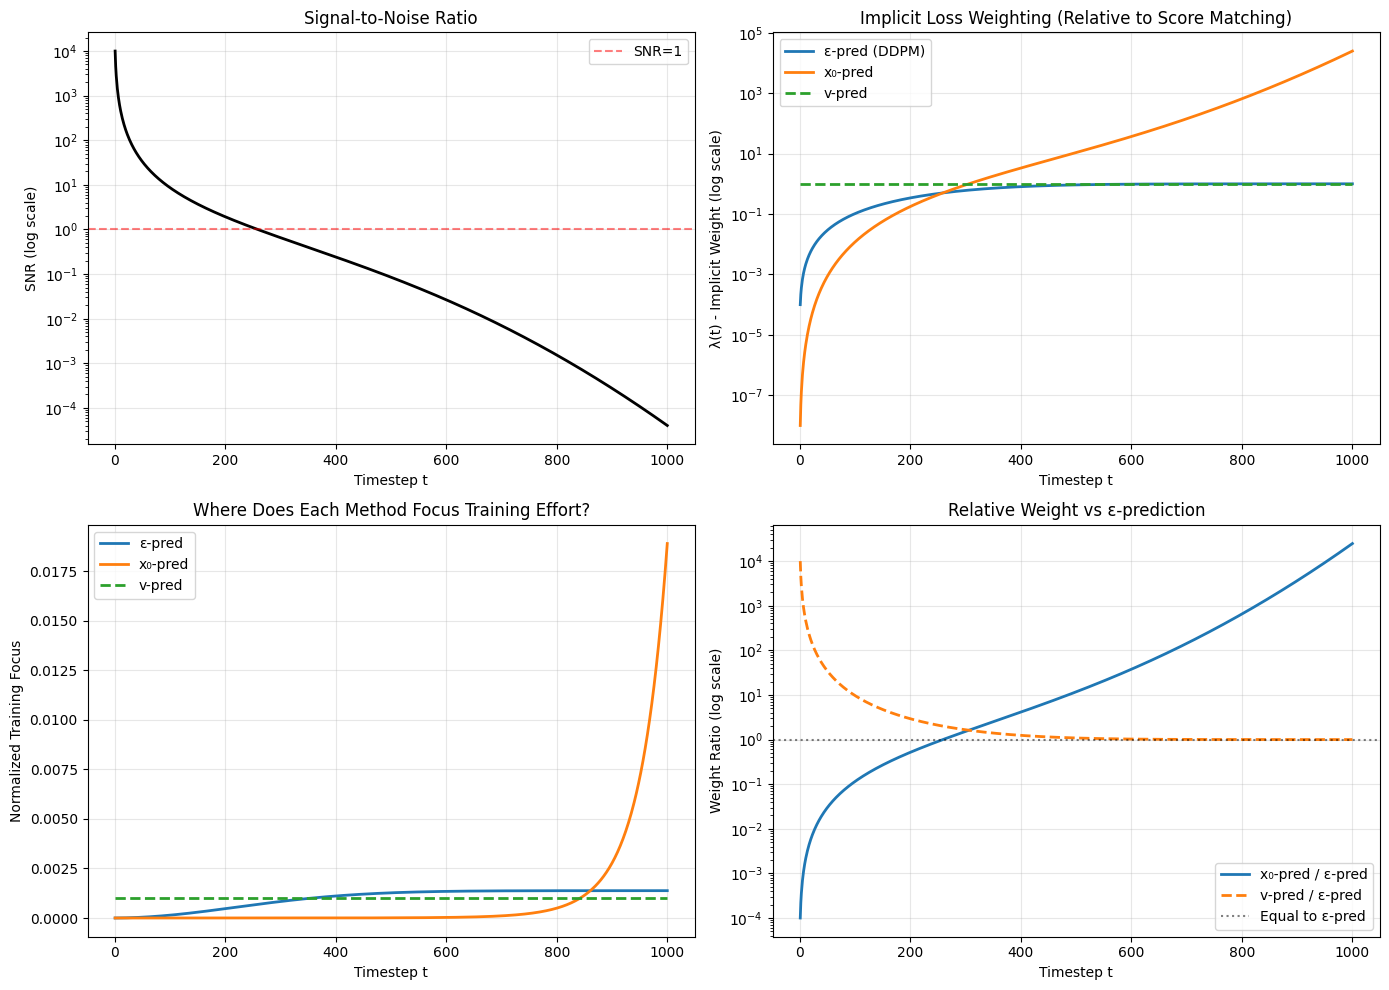


IMPLICIT LOSS WEIGHTS: How Different Parameterizations Weight Timesteps
     t        SNR    λ(ε-pred)     λ(x₀-pred)    λ(v-pred)   x₀/ε ratio
----------------------------------------------------------------------
     1   9999.000     0.000100       0.000000     1.000000         0.00x
   100      8.710     0.102982       0.011823     1.000000         0.11x
   250      1.101     0.475915       0.432171     1.000000         0.91x
   500      0.085     0.921413      10.803299     1.000000        11.72x
   750      0.003     0.996649     296.461765     1.000000       297.46x
   950      0.000     0.999892    9248.832406     1.000000      9249.83x
  1000      0.000     0.999960   24775.990702     1.000000     24776.99x


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Loss Weighting & Objective: Implicit Weights from Parameterization
# ------------------------------------------------------------------
# Key: When using MSE on different targets, we implicitly apply different
# weights λ(t) to the underlying Score Matching objective.
#
# Standard Score Matching loss (with tight ELBO weight):
#   L_SM = E[ sigma_t^2 * ||s_theta - s_true||^2 ]
#
# When predicting different targets with simple MSE, we get:
#   L = E[ lambda(t) * ||s_theta - s_true||^2 ]
#
# The lambda(t) tells us how much we weight different timesteps.

# Reuse noise schedule
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

alpha_t = np.sqrt(alpha_bars)      # Signal coefficient
sigma_t = np.sqrt(1 - alpha_bars)  # Noise coefficient
snr = alpha_t**2 / sigma_t**2      # Signal-to-Noise Ratio

# ------------------------------------------------------------------
# Derivation of Implicit Weights λ(t)
# ------------------------------------------------------------------
# We derive what weight is applied to score matching when using MSE loss.

# 1. ε-prediction (DDPM): predict noise ε
#    Relationship: ε = -sigma_t * score
#    Loss: ||ε_θ - ε||^2 = sigma_t^2 * ||score_θ - score||^2
#    → Implicit λ(t) = sigma_t^2 (baseline Score Matching weight)
lambda_eps = sigma_t**2

# 2. x₀-prediction: predict clean data x₀
#    Relationship: x₀ = (x_t - sigma_t * ε) / alpha_t
#    Loss: ||x₀_θ - x₀||^2
#    Converting to ε: ||(x_t - sigma_t*ε_θ)/alpha_t - (x_t - sigma_t*ε)/alpha_t||^2
#                   = (sigma_t^2 / alpha_t^2) * ||ε_θ - ε||^2
#                   = (sigma_t^4 / alpha_t^2) * ||score_θ - score||^2
#    → Implicit λ(t) = sigma_t^4 / alpha_t^2 = sigma_t^2 / SNR
#    WARNING: Explodes as alpha_t → 0 (high noise regime is unstable!)
lambda_x0 = sigma_t**4 / (alpha_t**2 + 1e-10)  # Add epsilon to avoid division by zero

# 3. v-prediction: predict velocity v = alpha_t * ε - sigma_t * x₀
#    This parameterization is designed to have uniform weighting.
#    For VP schedule with alpha_t^2 + sigma_t^2 = 1:
#    Loss: ||v_θ - v||^2 ≈ ||score_θ - score||^2  (approximately)
#    → Implicit λ(t) ≈ 1 (constant, balanced across timesteps)
lambda_v = np.ones_like(sigma_t)  # Approximately constant for VP schedule

# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------
timesteps = np.arange(1, T + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: SNR across timesteps
axes[0, 0].semilogy(timesteps, snr, color='black', linewidth=2)
axes[0, 0].set_xlabel("Timestep t")
axes[0, 0].set_ylabel("SNR (log scale)")
axes[0, 0].set_title("Signal-to-Noise Ratio")
axes[0, 0].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='SNR=1')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Implicit λ(t) for each parameterization (log scale)
axes[0, 1].semilogy(timesteps, lambda_eps, label='ε-pred (DDPM)', linewidth=2)
axes[0, 1].semilogy(timesteps, lambda_x0, label='x₀-pred', linewidth=2)
axes[0, 1].semilogy(timesteps, lambda_v, label='v-pred', linewidth=2, linestyle='--')
axes[0, 1].set_xlabel("Timestep t")
axes[0, 1].set_ylabel("λ(t) - Implicit Weight (log scale)")
axes[0, 1].set_title("Implicit Loss Weighting (Relative to Score Matching)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Relative weighting (normalized to show distribution)
# Normalize so total "training effort" sums to 1
lambda_eps_normalized = lambda_eps / lambda_eps.sum()
lambda_x0_normalized = lambda_x0 / lambda_x0.sum()
lambda_v_normalized = lambda_v / lambda_v.sum()

axes[1, 0].plot(timesteps, lambda_eps_normalized, label='ε-pred', linewidth=2)
axes[1, 0].plot(timesteps, lambda_x0_normalized, label='x₀-pred', linewidth=2)
axes[1, 0].plot(timesteps, lambda_v_normalized, label='v-pred', linewidth=2, linestyle='--')
axes[1, 0].set_xlabel("Timestep t")
axes[1, 0].set_ylabel("Normalized Training Focus")
axes[1, 0].set_title("Where Does Each Method Focus Training Effort?")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Ratio to baseline (how much more/less weight than ε-pred)
axes[1, 1].semilogy(timesteps, lambda_x0 / lambda_eps, label='x₀-pred / ε-pred', linewidth=2)
axes[1, 1].semilogy(timesteps, lambda_v / lambda_eps, label='v-pred / ε-pred', linewidth=2, linestyle='--')
axes[1, 1].axhline(y=1, color='black', linestyle=':', alpha=0.5, label='Equal to ε-pred')
axes[1, 1].set_xlabel("Timestep t")
axes[1, 1].set_ylabel("Weight Ratio (log scale)")
axes[1, 1].set_title("Relative Weight vs ε-prediction")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Numerical Analysis
# ------------------------------------------------------------------
print("\n" + "="*70)
print("IMPLICIT LOSS WEIGHTS: How Different Parameterizations Weight Timesteps")
print("="*70)
print(f"{'t':>6} {'SNR':>10} {'λ(ε-pred)':>12} {'λ(x₀-pred)':>14} {'λ(v-pred)':>12} {'x₀/ε ratio':>12}")
print("-" * 70)

for t in [1, 100, 250, 500, 750, 950, 1000]:
    idx = t - 1
    ratio = lambda_x0[idx] / lambda_eps[idx]
    print(f"{t:>6} {snr[idx]:>10.3f} {lambda_eps[idx]:>12.6f} {lambda_x0[idx]:>14.6f} "
          f"{lambda_v[idx]:>12.6f} {ratio:>12.2f}x")


### **1.3 Generative Sampling**

#### **1.3.1 Numerical SDE Solver**

As we established in the previous section, the mathematical foundation of diffusion models guarantees that for every forward process adding noise, there exists a corresponding **reverse SDE**:

$$d\mathbf{x} = [f(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d\bar{\mathbf{w}}$$

This reverse equation is the key to generation, as it allows us to reconstruct data from pure noise. To sample an image, we essentially need to solve this reverse SDE backward in time. However, since the exact equation depends on the unknown data distribution, we replace the unknown score term $\nabla_\mathbf{x} \log p_t(\mathbf{x})$ with the approximation provided by our trained **neural network** $s_\theta(\mathbf{x}, t)$. This effectively turns the generative process into a differential equation solving problem.

To solve this equation on a computer, we must use a **numerical method** to discretize the continuous timeline into finite steps. A fundamental and widely used algorithm for this purpose is the [**Euler–Maruyama method**](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method). It operates by partitioning the time interval into small segments of size $\Delta t$. At each iteration, the algorithm updates the current sample using two components:

1.  The first is a **deterministic drift term**, calculated as **$[f(\mathbf{x}, t) - g(t)^2 s_\theta(\mathbf{x}, t)] \Delta t$**. Here, the neural network $s_\theta$ acts as the substitute for the true score, guiding the noisy sample "uphill" toward the high-density regions of the data distribution.
2.  The second is a **stochastic diffusion term**, corresponding to **$g(t) d\bar{\mathbf{w}}$**. In the numerical step, this is implemented by adding standard **Gaussian noise** $\mathbf{z} \sim \mathcal{N}(0, \mathbf{I})$ scaled by **$g(t)\sqrt{\Delta t}$**. Note that the formula $dW = \sqrt{\Delta t} \cdot z$ for Brownian Motion here does hold true during its discretization.

This noise injection ensures the process maintains the correct statistical properties as it evolves toward the final image.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Numerical SDE Solver: Euler-Maruyama Method for Reverse Diffusion
# ------------------------------------------------------------------

# Setup: VP schedule
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

# ------------------------------------------------------------------
# Mock Score Network
# ------------------------------------------------------------------
def score_network(x_t, t_index):
    """Trained neural network that estimates the score: ∇_x log p_t(x)"""
    return np.random.randn(*x_t.shape) * 0.1

# ------------------------------------------------------------------
# Euler-Maruyama Sampler
# ------------------------------------------------------------------
def euler_maruyama_sampler(score_fn, betas, num_steps=50, data_shape=(3,)):
    """
    Sample from diffusion model using Euler-Maruyama numerical solver.

    Args:
        score_fn: Function that computes score given (x_t, t_index)
        betas: Array of beta values for the VP schedule
        num_steps: Number of discretization steps for solving SDE
        data_shape: Shape of data to generate

    Returns:
        Generated sample (denoised from pure noise)
    """
    T = len(betas)

    # 1. Initialize from prior: x_T ~ N(0, I)
    x = np.random.randn(*data_shape)
    print(f"Step 0: Starting from pure noise")

    # 2. Create reverse timestep schedule: T → 0
    timesteps = np.linspace(T-1, 0, num_steps).astype(int)
    dt = -timesteps[1] + timesteps[0]

    # 3. Iteratively denoise using reverse SDE
    for i, t_idx in enumerate(timesteps[:-1]):
        beta_t = betas[t_idx]
        score = score_fn(x, t_idx)

        # Reverse SDE: dx = [-0.5*beta*x - beta*score] dt + sqrt(beta) dw̄
        drift = -0.5 * beta_t * x - beta_t * score
        diffusion_coeff = np.sqrt(beta_t)

        # Euler-Maruyama update
        z = np.random.randn(*data_shape)
        x = x + drift * dt + diffusion_coeff * np.sqrt(dt) * z

        if i % (num_steps // 5) == 0:
            print(f"Step {i+1} (t≈{t_idx})")

    # 4. Final step: pure drift, no noise
    t_idx = timesteps[-1]
    beta_t = betas[t_idx]
    score = score_fn(x, t_idx)
    drift = -0.5 * beta_t * x - beta_t * score
    x = x + drift * dt

    print(f"Final step: Deterministic refinement")

    return x

# ------------------------------------------------------------------
# Run the sampler
# ------------------------------------------------------------------
print("="*70)
print("EULER-MARUYAMA SAMPLING")
print("="*70)

np.random.seed(42)
sample = euler_maruyama_sampler(
    score_fn=score_network,
    betas=betas,
    num_steps=50,
    data_shape=(3,)
)

print("="*70)


#### **1.3.2 Predictor-Corrector Sampler**

While standard numerical solvers like the Euler–Maruyama method (discussed in 1.3.1) are effective, they are essentially approximations. As we step backward in time, small discretization errors can accumulate, causing the generated sample to drift away from the true data manifold.

Fortunately, we can leverage a unique property of our model to fix this. At any given time step $t$, our trained neural network $s_\theta(\mathbf{x}, t)$ provides an estimate of the score $\nabla_\mathbf{x} \log p_t(\mathbf{x})$. This means that even if our sample is slightly "off," the network knows the direction toward the high-density regions of the distribution $p_t(\mathbf{x})$. We can exploit this using **Score-based MCMC** methods, such as **Langevin Dynamics** (https://arxiv.org/abs/1907.05600). Note that [MCMC](https://en.wikipedia.org/wiki/Markov_chain_Monte_Carlo) (Markov Chain Monte Carlo) is a technique used to sample from a probability distribution without having the full picture of the distribution.

Langevin Dynamics is an iterative process that produces samples from a distribution solely by following its score. Given a fixed time $t$, we can refine a sample $\mathbf{x}$ by running the following update rule for $N$ steps:

$$ \mathbf{x}_{i+1} = \mathbf{x}_{i} + \epsilon s_\theta(\mathbf{x}_i, t) + \sqrt{2\epsilon} \mathbf{z}_i $$

Here, $\epsilon > 0$ is a small step size, and $\mathbf{z}_i \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ is standard Gaussian noise. If we run this long enough, the sample $\mathbf{x}$ will converge to the distribution $p_t(\mathbf{x})$.

The **Predictor-Corrector (PC)** sampler combines the best of both worlds:
1.  **The Predictor:** First, we use a numerical SDE solver (like Euler–Maruyama) to predict the state at the next time step, moving from $\mathbf{x}_t$ to an estimate of $\mathbf{x}_{t-\Delta t}$.
2.  **The Corrector:** Before moving to the next time step, we pause the simulation and run several steps of Langevin Dynamics (the MCMC rule above). This "corrects" the predicted sample, pushing it back toward the high-density regions of the marginal distribution $p_{t-\Delta t}(\mathbf{x})$.

By alternating between predicting (moving along the timeline) and correcting (refining the sample quality), PC samplers effectively prevent error accumulation and typically generate higher-quality images than standard SDE solvers alone.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Predictor-Corrector Sampler
# ------------------------------------------------------------------
# Combines SDE solver (Predictor) with MCMC refinement (Corrector)
#
# Key idea:
# 1. PREDICTOR: Use Euler-Maruyama to move from t to t-Δt
# 2. CORRECTOR: Run Langevin MCMC to refine sample at t-Δt

# ------------------------------------------------------------------
# Setup: VP schedule
# ------------------------------------------------------------------
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

def score_network(x_t, t_index):
    """Mock score network"""
    return np.random.randn(*x_t.shape) * 0.1

# ------------------------------------------------------------------
# Langevin MCMC Corrector
# ------------------------------------------------------------------
def langevin_corrector(x, t_idx, score_fn, num_steps=5, snr=0.16):
    """
    Refine sample x at fixed time t using Langevin dynamics.

    Update: x += ε*score + √(2ε)*z
    """
    alpha_bar_t = alpha_bars[t_idx]

    for i in range(num_steps):
        score = score_fn(x, t_idx)

        # Adaptive step size based on SNR
        grad_norm = np.linalg.norm(score) + 1e-8
        noise_norm = np.sqrt(np.prod(x.shape))
        epsilon = 2 * (snr * noise_norm / grad_norm)**2

        # Langevin update
        z = np.random.randn(*x.shape)
        x = x + epsilon * score + np.sqrt(2 * epsilon) * z

    return x

# ------------------------------------------------------------------
# Predictor-Corrector Sampler
# ------------------------------------------------------------------
def predictor_corrector_sampler(score_fn, betas, num_steps=50,
                                 corrector_steps=1, snr=0.16,
                                 data_shape=(3,)):
    """
    Sample using Predictor-Corrector method.

    Args:
        score_fn: Score network
        betas: VP schedule parameters
        num_steps: Number of reverse steps (predictor iterations)
        corrector_steps: Number of Langevin MCMC steps per timestep
        snr: Signal-to-noise ratio for Langevin step size
        data_shape: Shape of data to generate
    """
    T = len(betas)

    # Initialize from prior
    x = np.random.randn(*data_shape)
    print(f"Starting from pure noise\n")

    # Reverse timestep schedule
    timesteps = np.linspace(T-1, 0, num_steps).astype(int)
    dt = -timesteps[1] + timesteps[0]

    for step_idx, t_idx in enumerate(timesteps[:-1]):
        # CORRECTOR: Refine current sample using Langevin MCMC
        x = langevin_corrector(x, t_idx, score_fn,
                               num_steps=corrector_steps, snr=snr)

        # PREDICTOR: Advance time using Euler-Maruyama
        beta_t = betas[t_idx]
        score = score_fn(x, t_idx)

        drift = -0.5 * beta_t * x - beta_t * score
        diffusion_coeff = np.sqrt(beta_t)

        z = np.random.randn(*data_shape)
        x = x + drift * dt + diffusion_coeff * np.sqrt(dt) * z

        if step_idx % (num_steps // 5) == 0:
            print(f"Step {step_idx+1}/{num_steps} (t≈{t_idx})")

    # Final step: deterministic
    t_idx = timesteps[-1]
    x = langevin_corrector(x, t_idx, score_fn, num_steps=corrector_steps, snr=snr)
    beta_t = betas[t_idx]
    score = score_fn(x, t_idx)
    drift = -0.5 * beta_t * x - beta_t * score
    x = x + drift * dt

    print(f"Sampling complete\n")

    return x

# ------------------------------------------------------------------
# Run sampler
# ------------------------------------------------------------------
print("="*70)
print("PREDICTOR-CORRECTOR SAMPLER")
print("="*70)

np.random.seed(42)

sample = predictor_corrector_sampler(
    score_fn=score_network,
    betas=betas,
    num_steps=20,
    corrector_steps=3,
    snr=0.16,
    data_shape=(3,)
)

print("="*70)


#### **1.3.3 Numerical ODE Solver**

Beyond stochastic methods, there is a fascinating connection between diffusion processes and deterministic flows. Mathematical theory shows that for any SDE of the form $d \mathbf{x} = f(\mathbf{x}, t) d t + g(t) d \mathbf{w}$, there exists an associated **Ordinary Differential Equation (ODE)** whose trajectories share the exact same marginal probability densities $p_t(\mathbf{x})$ as the SDE.

We call this the **Probability Flow ODE**. By replacing the unknown score with our neural network $s_\theta(\mathbf{x}, t)$, the equation is defined as:

$$ d \mathbf{x} = \bigg[f(\mathbf{x}, t) - \frac{1}{2}g(t)^2 s_\theta(\mathbf{x}, t)\bigg] dt $$

Unlike the SDE, this equation has no stochastic term ($d\mathbf{w}$). This means that if we start from a fixed noise vector $\mathbf{x}_T$, the generation process follows a completely deterministic trajectory to the final image $\mathbf{x}_0$. This allows for advanced sampling techniques and enables us to treat the generative process as a smooth flow of probability mass.

While the concepts of Numerical SDEs, PC samplers, and continuous-time ODEs might seem abstract, the intuition behind the ODE solver is actually quite grounded. Just as with SDEs, there are various numerical methods available to solve this equation.

If we look at one of the most widely used ODE solvers, **DDIM (Denoising Diffusion Implicit Models, https://arxiv.org/abs/2010.02502)**, it operates via a predict and reconstruct strategy. Recall the forward process equation relating the clean data $\mathbf{x}_0$ to the noisy data $\mathbf{x}_t$:

$$ \mathbf{x}_t = \alpha_t \mathbf{x}_0 + \sigma_t \epsilon $$

Solving the Probability Flow ODE with DDIM is effectively performing the following steps at each iteration:
1.  **Predict Noise:** The model observes $\mathbf{x}_t$ and predicts the noise component $\epsilon_\theta(\mathbf{x}_t, t)$.
2.  **Estimate Data:** We use this prediction to invert the equation above as $\hat{\mathbf{x}_0}=\frac{\mathbf{x}_t-\sigma_t\cdot\epsilon_\theta(\mathbf{x}_t,t)}{\alpha_t}$, solving for an estimated clean image $\hat{\mathbf{x}_0}$.
3.  **Reconstruct:** Using this estimated $\hat{\mathbf{x}_0}$ and the known schedule parameters for the next step ($\alpha_{t-1}, \sigma_{t-1}$), we deterministically calculate $\mathbf{x}_{t-1}=\alpha_{t-1}\hat{\mathbf{x}_0}+\sigma_{t-1}\cdot \epsilon_\theta(\mathbf{x}_t,t)$.

In this view, the differential equation is simply a formal way of describing this iterative process of predicting the clean image and re-mixing it to move one step closer to the data distribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Numerical ODE Solver: DDIM (Denoising Diffusion Implicit Models)
# ------------------------------------------------------------------
# Key idea: Replace stochastic SDE with deterministic ODE
#
# DDIM process at each step t → t-1:
#   1. Predict noise: ε_θ(x_t, t)
#   2. Estimate clean data: x̂_0 = (x_t - σ_t*ε_θ) / α_t
#   3. Reconstruct: x_{t-1} = α_{t-1}*x̂_0 + σ_{t-1}*ε_θ

# ------------------------------------------------------------------
# Setup: VP schedule
# ------------------------------------------------------------------
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

alpha_t = np.sqrt(alpha_bars)
sigma_t = np.sqrt(1 - alpha_bars)

def noise_prediction_network(x_t, t_index):
    """Mock neural network that predicts noise ε from noisy input"""
    return np.random.randn(*x_t.shape) * 0.1

# ------------------------------------------------------------------
# DDIM Sampler (eta=0, fully deterministic)
# ------------------------------------------------------------------
def ddim_sampler(model, alpha_t, sigma_t, num_steps=50, data_shape=(3,)):
    """
    Sample using DDIM (Probability Flow ODE solver).

    Args:
        model: Noise prediction network ε_θ(x_t, t)
        alpha_t: Signal coefficients for all timesteps
        sigma_t: Noise coefficients for all timesteps
        num_steps: Number of denoising steps
        data_shape: Shape of data to generate
    """
    T = len(alpha_t)

    # Initialize from prior
    x = np.random.randn(*data_shape)
    print(f"Step 0: Starting from pure noise\n")

    # Reverse timestep schedule (can skip steps for speed)
    timesteps = np.linspace(T-1, 0, num_steps).astype(int)

    # DDIM reverse process
    for i, t_idx in enumerate(timesteps[:-1]):
        t_next_idx = timesteps[i + 1]

        alpha_t_curr = alpha_t[t_idx]
        sigma_t_curr = sigma_t[t_idx]
        alpha_t_next = alpha_t[t_next_idx]
        sigma_t_next = sigma_t[t_next_idx]

        # Step 1: Predict noise
        epsilon_pred = model(x, t_idx)

        # Step 2: Estimate clean data
        x0_pred = (x - sigma_t_curr * epsilon_pred) / alpha_t_curr

        # Step 3: Reconstruct next state
        x = alpha_t_next * x0_pred + sigma_t_next * epsilon_pred

        if i % (num_steps // 5) == 0:
            print(f"Step {i+1}/{num_steps-1} (t={t_idx} → {t_next_idx})")

    print(f"Sampling complete\n")

    return x

# ------------------------------------------------------------------
# Run DDIM Sampler
# ------------------------------------------------------------------
print("="*70)
print("DDIM SAMPLER (Deterministic)")
print("="*70)

np.random.seed(42)

sample = ddim_sampler(
    model=noise_prediction_network,
    alpha_t=alpha_t,
    sigma_t=sigma_t,
    num_steps=20,
    data_shape=(3,)
)


### **1.4 Flow Matching**

As we discussed in the previous section, every diffusion model based on SDEs has an equivalent **Probability Flow ODE** that shares the exact same marginal distributions. This is a crucial insight because it means that when we train a standard diffusion model, we are implicitly learning this deterministic ODE trajectory as well. In practice, this deterministic path offers a major advantage: it allows for **faster sampling** with fewer steps compared to stochastic methods. Because of this efficiency, the ODE formulation has become the preferred choice for modern, large-scale applications.

This brings us to **Flow Matching**, a concept introduced in 2022 (https://arxiv.org/abs/2210.02747) that has recently become very popular. Despite the new name, it is not a fundamentally new generative method. Instead, it is best understood as a specific "recipe" for modeling this ODE. Flow Matching is defined by two main choices: it uses a **linear interpolation** for the noise schedule, typically defined as
$$
\mathbf{x}_t = (1 - t)\mathbf{x}_0 + t \epsilon
$$
and parameterizes the neural network using **v-prediction** (predicting the velocity of the flow). If a model uses this specific combination of a straight-line path and velocity prediction, it is effectively performing Flow Matching.

Although the original paper discusses theoretical connections to **Optimal Transport**, the mathematical core remains within the broader diffusion framework. Recent research, such as **TrigFlow** (https://arxiv.org/abs/2410.11081), has successfully unified these approaches, proving that Flow Matching is mathematically consistent with earlier models like DDPM and Score SDE. Therefore, you do not need to view it as a separate paradigm. It is simply a highly effective configuration of parameterization and scheduling that happens to work exceptionally well for training large models, which explains its widespread adoption today.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Flow Matching: Linear Interpolation + Velocity Prediction
# ------------------------------------------------------------------
# Key idea: Directly model the ODE velocity field
#
# Forward process (linear interpolation):
#   x_t = (1-t)*x_0 + t*ε,  where t ∈ [0,1], ε ~ N(0,I)
#
# Velocity field (what the network learns):
#   v_t(x) = dx/dt = ε - x_0
#
# Network parameterization:
#   v_θ(x_t, t) ≈ v_t(x)
#
# Training objective:
#   L = ||v_θ(x_t, t) - (ε - x_0)||²
#
# Sampling (ODE integration):
#   dx/dt = v_θ(x_t, t)
#   Start from x_1 ~ N(0,I), integrate backward to x_0

# ------------------------------------------------------------------
# Setup: Linear schedule (t from 0 to 1)
# ------------------------------------------------------------------
num_steps = 1000
t_schedule = np.linspace(0, 1, num_steps)

def velocity_network(x_t, t):
    """
    Mock neural network that predicts velocity v_θ(x_t, t)

    In practice: U-Net trained with ||v_θ(x_t,t) - (ε-x_0)||²
    """
    return np.random.randn(*x_t.shape) * 0.1

# ------------------------------------------------------------------
# Flow Matching Sampler (Euler ODE solver)
# ------------------------------------------------------------------
def flow_matching_sampler(model, num_steps=50, data_shape=(3,)):
    """
    Sample using Flow Matching (integrate velocity field ODE).

    Args:
        model: Velocity prediction network v_θ(x_t, t)
        num_steps: Number of integration steps
        data_shape: Shape of data to generate
    """
    # Initialize from prior: x_1 ~ N(0, I)
    x = np.random.randn(*data_shape)
    print(f"Step 0: Starting from pure noise (t=1)\n")

    # Reverse time schedule: t=1 → t=0
    t_schedule = np.linspace(1.0, 0.0, num_steps)
    dt = -1.0 / (num_steps - 1)

    # ODE integration: dx = v_θ(x,t) * dt
    for i, t in enumerate(t_schedule[:-1]):
        # Predict velocity at current state
        v = model(x, t)

        # Euler step: x_{t-dt} = x_t + v*dt
        x = x + v * dt

        if i % (num_steps // 5) == 0:
            print(f"Step {i+1}/{num_steps-1} (t={t:.3f} → {t+dt:.3f})")

    print(f"Sampling complete (t=0)\n")

    return x

# ------------------------------------------------------------------
# Training: Generate one training sample
# ------------------------------------------------------------------
def flow_matching_training_step(x0, data_shape=(3,)):
    """
    Demonstrate one Flow Matching training iteration.

    Training process:
    1. Sample clean data x_0
    2. Sample noise ε ~ N(0,I)
    3. Sample time t ~ Uniform[0,1]
    4. Compute x_t = (1-t)*x_0 + t*ε
    5. Compute target velocity: v_target = ε - x_0
    6. Train: minimize ||v_θ(x_t, t) - v_target||²
    """
    # Sample noise and time
    epsilon = np.random.randn(*data_shape)
    t = np.random.uniform(0, 1)

    # Forward process: interpolate between data and noise
    x_t = (1 - t) * x0 + t * epsilon

    # Target velocity (what network should predict)
    v_target = epsilon - x0

    # Mock network prediction
    v_pred = velocity_network(x_t, t)

    # Loss (in practice, backprop through this)
    loss = np.mean((v_pred - v_target)**2)

    print(f"Training step at t={t:.3f}:")
    print(f"  x_0 (clean): {x0}")
    print(f"  ε (noise): {epsilon}")
    print(f"  x_t (interpolated): {x_t}")
    print(f"  v_target: {v_target}")
    print(f"  Loss: {loss:.6f}\n")

    return loss

# ------------------------------------------------------------------
# Run Flow Matching
# ------------------------------------------------------------------
print("="*70)
print("FLOW MATCHING")
print("="*70)

# Demonstrate training
print("--- TRAINING EXAMPLE ---\n")
np.random.seed(42)
clean_data = np.array([1.0, 0.5, -0.3])
flow_matching_training_step(clean_data, data_shape=(3,))

# Demonstrate sampling
print("--- SAMPLING ---\n")
np.random.seed(42)
sample = flow_matching_sampler(
    model=velocity_network,
    num_steps=20,
    data_shape=(3,)
)


### **1.5 Exercise: Building a Toy Diffusion Model**

In this exercise, you will implement the core logic of a Denoising Diffusion Probabilistic Model (DDPM). Unlike GANs, which use adversarial training, Diffusion models learn to reverse a gradual noise process. We have provided the U-Net architecture and data tools; your task is to implement the **forward noise process** and the **reverse sampling process**.

**How does it work?**
Diffusion training is based on a single idea: **predicting noise**. We take a clean image, add Gaussian noise to it based on a schedule (timestep $t$), and ask the neural network to figure out exactly what noise was added. If the model can predict the noise, we can subtract it to recover the image.

You need to complete three key `TODO` blocks:

1.  **Forward Process (`q_sample`):** Implement the mathematical formula that adds noise to an image $x_0$ to create a noisy version $x_t$. This is the "VP Schedule" equation involving $\sqrt{\bar{\alpha}_t}$.
2.  **Training Loop:** Write the training step. You must sample random timesteps, add noise using your forward process, and calculate the MSE loss between the *actual* noise and the *predicted* noise.
3.  **Inference (`ddim_sample`):** Implement the reverse logic. Using the predicted noise, you will first algebraically solve for the clean image $x_0$, and then use the forward formula again to move to the previous timestep $x_{t-1}$.

---

### **Reference Formulas**
*   **Forward Process:** $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$
*   **Reverse Step (DDIM):**
    1.  Estimate $x_0$ by reversing the forward process.
    2.  Calculate $x_{t-1}$ by re-applying the forward process to your estimated $x_0$.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import math

# ==========================================
# 1. Configuration
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 16
BATCH_SIZE = 128
EPOCHS = 1000
LR = 1e-3

# Diffusion Hyperparameters
TIMESTEPS = 1000  # T in DDPM
BETA_START = 1e-4
BETA_END = 0.02

In [ ]:
# ==========================================
# 2. Create "Toy" Dataset (Same as GAN)
# ==========================================
def create_toy_data(n_samples=1000):
    data = torch.zeros(n_samples, 1, IMG_SIZE, IMG_SIZE) - 1.0 # Background = -1
    for i in range(n_samples):
        mode = i % 4
        if mode == 0: # Square
            data[i, 0, 4:12, 4:12] = 1.0
            data[i, 0, 6:10, 6:10] = -1.0
        elif mode == 1: # Cross
            data[i, 0, 2:14, 7:9] = 1.0
            data[i, 0, 7:9, 2:14] = 1.0
        elif mode == 2: # Vertical Bar
            data[i, 0, 2:14, 3:6] = 1.0
        elif mode == 3: # Horizontal Bar
            data[i, 0, 10:13, 2:14] = 1.0
    return data

# Prepare Data
real_data = create_toy_data(1024)
dataset = TensorDataset(real_data)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


In [ ]:
# ==========================================
# 3. Diffusion Utilities (VP Schedule)
# ==========================================
class DiffusionManager:
    def __init__(self, timesteps=TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END, device=DEVICE):
        self.timesteps = timesteps
        self.device = device

        # Define Beta schedule (Linear)
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)

        # Calculate Alphas
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0]).to(device), self.alphas_cumprod[:-1]])

        # Calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

    # Forward Process: Add noise to x_0 to get x_t
    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)

        # ==========================================
        # TODO: Implement the Forward Process Equation
        # ==========================================
        # The formula for the VP schedule is:
        # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
        #
        # Variables available:
        # - x_start: x_0
        # - noise: Gaussian noise
        # - sqrt_alphas_cumprod_t: sqrt(alpha_bar_t)
        # - sqrt_one_minus_alphas_cumprod_t: sqrt(1 - alpha_bar_t)

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


In [ ]:
# ==========================================
# 4. Micro U-Net Architecture
# ==========================================
# A very simple U-Net to predict noise
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time Embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)

class SimpleUnet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1
        down_channels = (32, 64, 128)
        up_channels = (128, 64, 32)
        out_dim = 1
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) \
            for i in range(len(down_channels)-1)
        ])

        # Upsample
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) \
            for i in range(len(up_channels)-1)
        ])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embed time
        t = self.time_mlp(timestep)
        # Initial Conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual connection
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)

# Initialize
model = SimpleUnet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()
diff_manager = DiffusionManager()

In [ ]:
# ==========================================
# 5. Training Loop
# ==========================================
print("Starting Diffusion training...")
losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    for i, (real_imgs,) in enumerate(dataloader):
        real_imgs = real_imgs.to(DEVICE)
        b_size = real_imgs.size(0)

        optimizer.zero_grad()

        # ==========================================
        # TODO: Implement the Diffusion Training Step
        # ==========================================
        # 1. Sample random timesteps 't' for the batch (0 to TIMESTEPS).
        # 2. Generate random Gaussian 'noise' with the same shape as real_imgs.
        # 3. Create 'x_noisy' by adding noise to real_imgs using diff_manager.q_sample().
        # 4. Predict the noise 'noise_pred' using the model(x_noisy, t).
        # 5. Calculate MSE 'loss' between the predicted noise and the actual noise.

        t = torch.randint(0, TIMESTEPS, size=(b_size,), device=DEVICE).long()
        noise = torch.randn_like(real_imgs)
        x_noisy = diff_manager.q_sample(real_imgs, t, noise)
        noise_pred = model(x_noisy, t)
        loss = loss_fn(noise_pred, noise)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}")

Starting Diffusion training...
Epoch [50/1000] Loss: 0.0171
Epoch [100/1000] Loss: 0.0141
Epoch [150/1000] Loss: 0.0088
Epoch [200/1000] Loss: 0.0071
Epoch [250/1000] Loss: 0.0071
Epoch [300/1000] Loss: 0.0064
Epoch [350/1000] Loss: 0.0051
Epoch [400/1000] Loss: 0.0066
Epoch [450/1000] Loss: 0.0042
Epoch [500/1000] Loss: 0.0052
Epoch [550/1000] Loss: 0.0053
Epoch [600/1000] Loss: 0.0042
Epoch [650/1000] Loss: 0.0041
Epoch [700/1000] Loss: 0.0040
Epoch [750/1000] Loss: 0.0040
Epoch [800/1000] Loss: 0.0041
Epoch [850/1000] Loss: 0.0030
Epoch [900/1000] Loss: 0.0040
Epoch [950/1000] Loss: 0.0038
Epoch [1000/1000] Loss: 0.0043


In [ ]:
# ==========================================
# 6. DDIM Sampling (Inference)
# ==========================================
@torch.no_grad()
def ddim_sample(model, n_samples=16, ddim_timesteps=50):
    # Create a sequence of timesteps for sampling (e.g., 1000 -> 0 in 50 steps)
    c = TIMESTEPS // ddim_timesteps
    time_seq = list(range(0, TIMESTEPS, c)) + [TIMESTEPS - 1]
    time_seq = time_seq[::-1] # Reverse: [999, ..., 0]

    # Start from pure noise
    x = torch.randn(n_samples, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)

    for i in range(len(time_seq) - 1):
        t = time_seq[i]
        t_prev = time_seq[i+1]

        # Create batch of current timestep
        t_tensor = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)

        # 1. Predict noise
        noise_pred = model(x, t_tensor)

        # Get alpha cumulative products for current t and next step t_prev
        alpha_cumprod_t = diff_manager.alphas_cumprod[t]
        alpha_cumprod_t_prev = diff_manager.alphas_cumprod[t_prev]

        # ==========================================
        # TODO 1: Revert the Forward Process to estimate x_0
        # ==========================================
        # We know: x_t = sqrt(alpha_t) * x_0 + sqrt(1 - alpha_t) * noise
        # We need to invert this to find x_0 based on x (which is x_t) and noise_pred.
        pred_x0 = (x - torch.sqrt(1 - alpha_cumprod_t) * noise_pred) / torch.sqrt(alpha_cumprod_t)

        # Clip to image range to keep stability
        pred_x0 = torch.clamp(pred_x0, -1, 1)

        # ==========================================
        # TODO 2: Compute x_{t-1} (Deterministic Update)
        # ==========================================
        # In DDIM (with eta=0), we assume the "direction" to x_t is deterministic.
        # We effectively re-apply the forward process formula, but targeting t-1.

        # NOTE: You can try removing the second term when using this toy example,
        #       as the predicted sample is expected to have no textures but patterns.
        # x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0
        x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + torch.sqrt(1 - alpha_cumprod_t_prev) * noise_pred

    return x


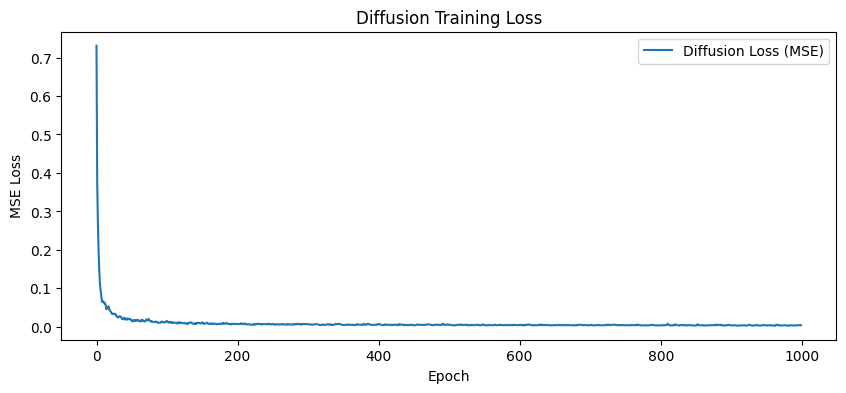

Generating samples with DDIM...


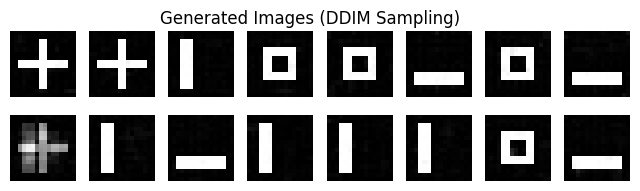

In [ ]:
# ==========================================
# 7. Visualization
# ==========================================

# A. Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Diffusion Loss (MSE)")
plt.title("Diffusion Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# B. Generated Samples
model.eval()
print("Generating samples with DDIM...")
gen_imgs = ddim_sample(model, n_samples=16, ddim_timesteps=8).cpu()

plt.figure(figsize=(8, 2))
plt.suptitle("Generated Images (DDIM Sampling)")
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
plt.show()

## Part 2: Controllable and Latent Diffusion

This part focuses on making diffusion models both steerable and efficient. We will first explore **Conditioning Mechanisms** that allow us to control and guide the image generation process. Then, we will introduce **Latent Diffusion Models**, a key architecture that significantly improves computational efficiency by performing diffusion in a compressed latent space.

### **2.1 Conditioning Mechanisms**

#### **2.1.1 Classifier Guidance**

In the previous section, we learned about the basic diffusion process. However, standard diffusion models are usually **unconditional**. This means they generate images randomly from the learned data distribution. You might get a cat, a dog, or a car, and you cannot choose which one appears. To fix this, we need a way to control the output. This brings us to **Classifier Guidance** (https://arxiv.org/abs/2105.05233).

To make this work, we need to do something extra during the **Training** phase. In addition to the main diffusion model, we must train a separate **classifier model**. This classifier takes an image as input and predicts its class label, such as "dog" or "cat." Crucially, this classifier must be trained on **noisy images**. It needs to learn how to recognize objects even when they are heavily corrupted by noise at different timesteps.

During **Inference**, we combine the diffusion model and the classifier to guide the generation. Let us look at how this changes the **DDIM** sampling steps we discussed earlier.

Recall that in standard DDIM, the model predicts a noise component $\epsilon_\theta(\mathbf{x}_t, t)$. In Classifier Guidance, we do not use this prediction directly. Instead, we calculate the **gradient** of the classifier with respect to the current image $\mathbf{x}_t$. This gradient tells us how to change the pixels to make the image look more like our target class $y$.

We combine the original noise prediction with this gradient to create a new, **modified noise** term $\hat{\epsilon_{}}$. The formula looks like this:

$$ \hat{\epsilon_{}} = \epsilon_\theta(\mathbf{x}_t, t) - s \cdot \sigma_t \cdot \nabla_{\mathbf{x}_t} \log p_\phi(y|\mathbf{x}_t) $$

In this equation, $s$ represents the **guidance scale**. This parameter controls how strongly we force the image to match the class label. We then take this modified $\hat{\epsilon_{}}$ and plug it back into the standard DDIM reconstruction step:

$$ \mathbf{x}_{t-1} = \alpha_{t-1}\hat{\mathbf{x}_0} + \sigma_{t-1}\cdot \hat{\epsilon_{}} $$

By shifting the noise component, we effectively steer the denoising process. The solver thinks it is removing random noise, but we are actually pushing the trajectory toward the specific object we want to generate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Classifier Guidance
# ------------------------------------------------------------------
# Goal: Control diffusion output using a separate classifier
#
# Training phase:
#   1. Train diffusion model (noise prediction)
#   2. Train classifier on noisy images: p_φ(y|x_t, t)
#
# Inference phase:
#   Modify DDIM with classifier gradient:
#   ε̂ = ε_θ(x_t,t) - s·σ_t·∇_x log p_φ(y|x_t)

# ------------------------------------------------------------------
# Setup: VP schedule
# ------------------------------------------------------------------
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

alpha_t = np.sqrt(alpha_bars)
sigma_t = np.sqrt(1 - alpha_bars)

# ------------------------------------------------------------------
# Models
# ------------------------------------------------------------------
def noise_prediction_network(x_t, t_index):
    """Trained diffusion model: predicts noise ε_θ(x_t, t)"""
    return np.random.randn(*x_t.shape) * 0.1

def noisy_classifier(x_t, t_index, y):
    """
    Trained classifier on noisy images: p_φ(y|x_t, t)

    Returns log probability for class y
    """
    # Mock: return random log probability
    return np.random.randn()

def classifier_gradient(x_t, t_index, y):
    """
    Gradient of classifier log probability: ∇_x log p_φ(y|x_t)

    In practice: backpropagate through classifier network
    """
    # Mock: return random gradient
    return np.random.randn(*x_t.shape) * 0.05

# ------------------------------------------------------------------
# Training: Classifier on noisy images
# ------------------------------------------------------------------
def train_noisy_classifier_step(x0, y, t_index):
    """
    Demonstrate one classifier training iteration.

    Training process:
    1. Sample clean data x_0 with label y
    2. Add noise: x_t = α_t·x_0 + σ_t·ε
    3. Train classifier: minimize -log p_φ(y|x_t, t)
    """
    # Forward diffusion: add noise
    epsilon = np.random.randn(*x0.shape)
    alpha = alpha_t[t_index]
    sigma = sigma_t[t_index]
    x_t = alpha * x0 + sigma * epsilon

    # Classifier prediction
    log_prob = noisy_classifier(x_t, t_index, y)
    loss = -log_prob  # Negative log likelihood

    print(f"Classifier training at t={t_index}:")
    print(f"  Label: {y}")
    print(f"  Noise level σ_t: {sigma:.4f}")
    print(f"  Training on noisy image x_t")
    print()

# ------------------------------------------------------------------
# Inference: DDIM with Classifier Guidance
# ------------------------------------------------------------------
def classifier_guided_ddim(noise_model, classifier_grad_fn,
                           target_class, guidance_scale,
                           alpha_t, sigma_t, num_steps=50,
                           data_shape=(3,)):
    """
    Sample using DDIM with Classifier Guidance.

    Args:
        noise_model: ε_θ(x_t, t)
        classifier_grad_fn: ∇_x log p_φ(y|x_t)
        target_class: Desired class label y
        guidance_scale: Strength of guidance (s)
        alpha_t, sigma_t: Diffusion schedule
        num_steps: Number of denoising steps
        data_shape: Shape of data to generate
    """
    T = len(alpha_t)

    # Initialize from prior
    x = np.random.randn(*data_shape)
    print(f"Starting classifier-guided sampling")
    print(f"Target class: {target_class}")
    print(f"Guidance scale: {guidance_scale}\n")

    # Reverse timestep schedule
    timesteps = np.linspace(T-1, 0, num_steps).astype(int)

    for i, t_idx in enumerate(timesteps[:-1]):
        t_next_idx = timesteps[i + 1]

        alpha_curr = alpha_t[t_idx]
        sigma_curr = sigma_t[t_idx]
        alpha_next = alpha_t[t_next_idx]
        sigma_next = sigma_t[t_next_idx]

        # Step 1: Predict noise (unconditional)
        epsilon_pred = noise_model(x, t_idx)

        # Step 2: Compute classifier gradient
        grad = classifier_grad_fn(x, t_idx, target_class)

        # Step 3: Modify noise prediction with guidance
        # ε̂ = ε_θ - s·σ_t·∇_x log p_φ(y|x_t)
        epsilon_guided = epsilon_pred - guidance_scale * sigma_curr * grad

        # Step 4: DDIM reconstruction with modified noise
        x0_pred = (x - sigma_curr * epsilon_guided) / alpha_curr
        x = alpha_next * x0_pred + sigma_next * epsilon_guided

        if i % (num_steps // 5) == 0:
            print(f"Step {i+1}/{num_steps-1} (t={t_idx})")

    print(f"Sampling complete\n")

    return x

# ------------------------------------------------------------------
# Run Classifier Guidance Pipeline
# ------------------------------------------------------------------
print("="*70)
print("CLASSIFIER GUIDANCE")
print("="*70)

# Phase 1: Training
print("--- PHASE 1: TRAINING ---\n")
print("1. Train diffusion model (standard)")
print("2. Train classifier on noisy images:\n")

np.random.seed(42)
clean_image = np.array([1.0, 0.5, -0.3])
label = "dog"
t_idx = 500

train_noisy_classifier_step(clean_image, label, t_idx)

# Phase 2: Inference
print("--- PHASE 2: INFERENCE ---\n")

np.random.seed(42)
sample = classifier_guided_ddim(
    noise_model=noise_prediction_network,
    classifier_grad_fn=classifier_gradient,
    target_class="cat",
    guidance_scale=3.0,
    alpha_t=alpha_t,
    sigma_t=sigma_t,
    num_steps=20,
    data_shape=(3,)
)


#### **2.1.2 Classifier-Free Guidance (CFG)**

While Classifier Guidance is effective, it has a significant practical drawback. It requires us to train an extra model. We must train a separate classifier specifically on noisy images, which complicates the training pipeline and increases the computational cost. To solve this, researchers introduced **Classifier-Free Guidance (CFG)** (https://arxiv.org/abs/2207.12598). This method achieves excellent control without needing an external classifier at all.

The core idea of CFG is to train a single diffusion model that can handle both conditional and unconditional generation. During **Training**, we usually provide the model with the condition $c$, such as a class label or a text prompt. However, with a certain probability (typically 10% to 20%), we randomly discard this condition. For text-to-image models, we replace the prompt with an **empty string**. For class-based models, we replace the label with a special **null token** $\emptyset$. This forces the model to learn both the conditional distribution $p(x|c)$ and the unconditional distribution $p(x)$ using the same set of weights.

During **Inference**, the sampling process becomes slightly more expensive. At every single timestep, we must perform **two forward passes** through the network. Taking DDIM sampler as an example, we compute both the conditional noise $\epsilon_\theta(x_t, c)$ and the unconditional noise $\epsilon_\theta(x_t, \emptyset)$ at every step. We then combine these two predictions to steer the generation process.

We calculate the final noise estimate $\hat{\epsilon}(x_t, c)$ using a linear combination of the two predictions. The formula is defined as follows:

$$ \hat{\epsilon_{}}(x_t, c) = \epsilon_\theta(x_t, \emptyset) + w \cdot (\epsilon_\theta(x_t, c) - \epsilon_\theta(x_t, \emptyset)) $$

In this equation, $w$ is the **guidance scale**. When $w$ is greater than 1, we are effectively taking the difference between the conditional and unconditional predictions and amplifying it. This pushes the image away from a generic result and strongly towards the specific condition we requested. We then use this new $\hat{\epsilon_{}}$ to update the image state $x_{t-1}$ using the standard sampling update rule.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Classifier-Free Guidance (CFG)
# ------------------------------------------------------------------
# Goal: Control diffusion without a separate classifier
#
# Training phase:
#   Train one model for both conditional and unconditional:
#   • With probability p (e.g., 10-20%): drop condition → ∅
#   • Model learns both ε_θ(x_t, c) and ε_θ(x_t, ∅)
#
# Inference phase:
#   Run two forward passes and combine:
#   ε̂ = ε_θ(x_t,∅) + w·(ε_θ(x_t,c) - ε_θ(x_t,∅))

# ------------------------------------------------------------------
# Setup: VP schedule
# ------------------------------------------------------------------
T = 1000
betas = np.linspace(0.0001, 0.02, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

alpha_t = np.sqrt(alpha_bars)
sigma_t = np.sqrt(1 - alpha_bars)

# ------------------------------------------------------------------
# Model
# ------------------------------------------------------------------
def conditional_noise_network(x_t, t_index, condition):
    """
    Trained diffusion model with conditional input.

    Args:
        x_t: Noisy image
        t_index: Timestep
        condition: Text prompt, class label, or None (∅)

    Returns:
        Predicted noise ε_θ(x_t, t, c)
    """
    # Mock: return slightly different noise based on condition
    base_noise = np.random.randn(*x_t.shape) * 0.1

    if condition is None:  # Unconditional
        return base_noise
    else:  # Conditional
        # In practice, condition is encoded and fed to U-Net
        return base_noise + np.random.randn(*x_t.shape) * 0.02

# ------------------------------------------------------------------
# Training: Conditional with random dropout
# ------------------------------------------------------------------
def cfg_training_step(x0, condition, t_index, dropout_prob=0.1):
    """
    Demonstrate one CFG training iteration.

    Training process:
    1. Sample clean data x_0 with condition c
    2. Randomly drop condition with probability p
    3. Add noise: x_t = α_t·x_0 + σ_t·ε
    4. Train: minimize ||ε_θ(x_t, t, c') - ε||²
       where c' is either c or ∅
    """
    # Randomly drop condition
    if np.random.rand() < dropout_prob:
        c_train = None  # Use null token ∅
        mode = "unconditional"
    else:
        c_train = condition
        mode = "conditional"

    # Forward diffusion: add noise
    epsilon_true = np.random.randn(*x0.shape)
    alpha = alpha_t[t_index]
    sigma = sigma_t[t_index]
    x_t = alpha * x0 + sigma * epsilon_true

    # Model prediction
    epsilon_pred = conditional_noise_network(x_t, t_index, c_train)

    # Loss
    loss = np.mean((epsilon_pred - epsilon_true)**2)

    print(f"CFG training at t={t_index}:")
    print(f"  Original condition: '{condition}'")
    print(f"  Training mode: {mode}")
    print(f"  (Condition dropped with p={dropout_prob})")
    print()

# ------------------------------------------------------------------
# Inference: DDIM with Classifier-Free Guidance
# ------------------------------------------------------------------
def classifier_free_guided_ddim(model, condition, guidance_scale,
                                alpha_t, sigma_t, num_steps=50,
                                data_shape=(3,)):
    """
    Sample using DDIM with Classifier-Free Guidance.

    Args:
        model: Conditional noise network ε_θ(x_t, t, c)
        condition: Target condition (text, class, etc.)
        guidance_scale: Strength of guidance (w)
        alpha_t, sigma_t: Diffusion schedule
        num_steps: Number of denoising steps
        data_shape: Shape of data to generate
    """
    T = len(alpha_t)

    # Initialize from prior
    x = np.random.randn(*data_shape)
    print(f"Starting CFG sampling")
    print(f"Condition: '{condition}'")
    print(f"Guidance scale: {guidance_scale}\n")

    # Reverse timestep schedule
    timesteps = np.linspace(T-1, 0, num_steps).astype(int)

    for i, t_idx in enumerate(timesteps[:-1]):
        t_next_idx = timesteps[i + 1]

        alpha_curr = alpha_t[t_idx]
        sigma_curr = sigma_t[t_idx]
        alpha_next = alpha_t[t_next_idx]
        sigma_next = sigma_t[t_next_idx]

        # Step 1: Unconditional prediction
        epsilon_uncond = model(x, t_idx, condition=None)

        # Step 2: Conditional prediction
        epsilon_cond = model(x, t_idx, condition=condition)

        # Step 3: Combine with guidance scale
        # ε̂ = ε_∅ + w·(ε_c - ε_∅)
        epsilon_guided = epsilon_uncond + guidance_scale * (epsilon_cond - epsilon_uncond)

        # Step 4: DDIM reconstruction
        x0_pred = (x - sigma_curr * epsilon_guided) / alpha_curr
        x = alpha_next * x0_pred + sigma_next * epsilon_guided

        if i % (num_steps // 5) == 0:
            print(f"Step {i+1}/{num_steps-1} (t={t_idx})")

    print(f"Sampling complete\n")

    return x

# ------------------------------------------------------------------
# Run CFG Pipeline
# ------------------------------------------------------------------
print("="*70)
print("CLASSIFIER-FREE GUIDANCE (CFG)")
print("="*70)

# Phase 1: Training
print("--- PHASE 1: TRAINING ---\n")
print("Train single model with random condition dropout:\n")

np.random.seed(42)
clean_image = np.array([1.0, 0.5, -0.3])
condition = "a photo of a cat"
t_idx = 500

# Simulate multiple training steps
for _ in range(3):
    cfg_training_step(clean_image, condition, t_idx, dropout_prob=0.15)

# Phase 2: Inference
print("\n--- PHASE 2: INFERENCE ---\n")

np.random.seed(42)
sample = classifier_free_guided_ddim(
    model=conditional_noise_network,
    condition="a photo of a dog",
    guidance_scale=7.5,
    alpha_t=alpha_t,
    sigma_t=sigma_t,
    num_steps=20,
    data_shape=(3,)
)



### **2.2 Latent Diffusion Models (LDM)**

#### **2.2.1 Explosion: Stable Diffusion 1.5 & XL**

<img src="https://viso.ai/wp-content/uploads/2024/07/stable-diffusion-architecture-1060x535.jpg" width="50%">

In earlier diffusion models, the process operated directly in **pixel space**. This approach worked for low-resolution images but became too computationally expensive for high-resolution generation beyond 512 pixels. To address this challenge, **Latent Diffusion Models** (LDMs) emerged. They shifted the diffusion process to a compressed space, enabling efficient high-quality image synthesis. This innovation sparked rapid growth in the open-source community. The most prominent examples are **Stable Diffusion 1.5**, which generates images at 512 resolution, and its successor **Stable Diffusion XL**, scaled up to 1024 resolution.

LDMs consist of three main components. First, a **Variational Autoencoder** (VAE) compresses images into a lower-dimensional latent representation. Second, **text encoders** convert user prompts into embeddings that guide the generation. Third, the core diffusion model operates in this latent space. In **Stable Diffusion 1.5** and **XL**, the VAE applies an 8x8 compression ratio. This reduces a 3x512x512 RGB image to a 4x64x64 latent tensor. As a result, the sequence length in attention mechanisms drops to 1/64 of the original, making training and inference far more efficient.

For text encoding, **Stable Diffusion 1.5** uses a single **CLIP** model. In contrast, **Stable Diffusion XL** employs two CLIP models of different sizes, which greatly improves the understanding of complex user prompts. The diffusion component in these models uses a **UNet** architecture, combining convolution-based ResNet blocks with attention-based Transformer blocks.

A critical step in all LDMs is the normalization of the latent space. Although VAEs theoretically push data toward a normal distribution, the actual encoded latents often have uncontrolled variance. To ensure numerical stability, we must align the latent distribution with the diffusion process, which targets a mean of 0 and variance of 1. This is achieved by calculating a **shift factor** and a **scale factor** from the training data and applying the formula: $z_{scaled} = (z - \text{shift_factor}) \times \text{scale_factor}$. Stable Diffusion models simplify this by using only a scale factor (setting the shift to 0) to ensure the latents are in a suitable range for the diffusion model to process.

> Visit https://huggingface.co/spaces/mvp-lab/70113_ImgGen_Diffusion_SD15xSDXL

#### **2.2.2 Controllability: ControlNet & LoRA**

While Latent Diffusion Models are powerful, relying solely on text prompts can be limiting. Text is excellent for describing content, but it struggles to define precise spatial structures or specific artistic styles. To address this, researchers developed methods to guide the generation process more strictly without retraining the entire model. Two of the most important techniques in this area are **ControlNet** and **LoRA**.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*tUQAYhwRV8OHzgpbGErjEg.png" width="50%">

**ControlNet** (https://arxiv.org/abs/2302.05543) is a neural network structure designed to add spatial conditioning to pre-trained diffusion models. It allows users to provide additional input images, such as edge maps, depth maps, or human pose skeletons, to guide the generation. The architecture works by locking the parameters of the original diffusion model and creating a trainable copy of its encoding layers. These two parts are connected via **zero convolution** layers. These layers are initialized with zeros, ensuring that the model behaves exactly like the original pre-trained model at the start of training. As training progresses, the model learns to incorporate the spatial guidance, allowing for precise control over the composition of the final image.


<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/2025/Shaoni/17-jul/Image_1.png" width="25%">

The second key technique is **Low-Rank Adaptation**, commonly known as **LoRA** (https://arxiv.org/abs/2106.09685). Fine-tuning a massive model like Stable Diffusion for a specific concept or style is computationally expensive and requires large storage. LoRA solves this by freezing the pre-trained model weights and injecting trainable **rank decomposition matrices** into the layers of the Transformer or UNet. Instead of updating the full weight matrix, we optimize these much smaller matrices.

This approach significantly reduces the number of trainable parameters. A typical LoRA file is often just a few megabytes, whereas a full model checkpoint can be several gigabytes. This efficiency allows users to easily switch between different LoRAs to change the artistic style, character, or object in the generated image without modifying the underlying base model.

> Visit https://huggingface.co/spaces/mvp-lab/70113_ImgGen_Diffusion_ControlNetxLoRA

#### **2.2.3 Scalability: FLUX & HiDream**

As Latent Diffusion Models grow in popularity, researchers focus on scaling them up for better performance. This involves increasing model size and improving architecture. Larger models with more parameters can capture complex patterns and generate higher-quality images. Two recent examples are **FLUX** and **HiDream**. These models push the boundaries of scalability in diffusion-based image generation.

<img src="https://github.com/lucidrains/mmdit/blob/main/mmdit.png?raw=true" width="25%">

**FLUX** is a 12 billion parameter model based on the **Multimodal Diffusion Transformer** (MMDiT) architecture. It uses only Transformer blocks and avoids convolutions entirely. In traditional UNet models, latent representations and text embeddings interact through cross-attention, where latents provide queries and text provides keys and values. In contrast, **MMDiT** encodes latents and text with separate parameters but processes them in the same attention context. This means both latents and text can act as queries, keys, and values. As a result, **FLUX** achieves stronger multimodal integration and generates more coherent images from diverse prompts.

<img src="https://arxiv.org/html/2505.22705v1/x3.png" width="50%">

**HiDream** introduces scalability through a Mixture of Experts (MoE) design with 17 billion parameters. It is probably the first large-scale MoE-based latent diffusion model for image generation publicly available. In an **MoE** system, a router selects which experts to activate for a given input, while experts are specialized sub-networks that handle different parts of the task. **HiDream** also includes shared experts that contribute to all inputs for better consistency. This setup provides huge capacity for modeling complex data, a feature adopted by many closed-source industrial models. Another key aspect is the use of large language models as text encoders. In **HiDream**, a version of **Llama** serves this role, enhancing the understanding of detailed text prompts.

> Visit https://huggingface.co/spaces/mvp-lab/70113_ImgGen_Diffusion_SDXLxFLUX

### **2.3 Exercise: Adding CFG to Toy Diffusion Model**

In this exercise, you will upgrade your Diffusion model to be **class-conditional**. Instead of generating random shapes, you will control whether the model generates a Square, Cross, Vertical Bar, or Horizontal Bar. You will also implement **Classifier-Free Guidance (CFG)**, the standard technique used by modern models (like Stable Diffusion) to force the image to strictly adhere to the prompt.

**How does it work?**
To enable CFG, we need a single model that can act as both a conditional generator (using a label) and an unconditional generator (using no label).
1.  **Training (Label Dropping):** During training, we randomly replace the real class label with a special "null" token (about 10% of the time). This forces the model to learn how to generate images even when it doesn't know the class.
2.  **Inference (Guidance):** We predict the noise twice: once *with* the label ($\epsilon_{cond}$) and once *without* ($\epsilon_{uncond}$). The difference between them represents the "essence" of that class. We amplify this difference to guide the generation.

You need to complete two key `TODO` blocks:

1.  **Training Loop:** Implement **Label Dropping**. Before passing data to the model, randomly replace the class labels with the "null" class index (`N_CLASSES`) with a probability of 0.1.
2.  **Inference (`ddim_sample_cfg`):** Implement the **CFG prediction logic**. You must predict noise for both the conditional and unconditional inputs, then combine them using the guidance scale.

---

### **Reference Formulas**
*   **CFG Equation:**
    $\epsilon_{pred} = \epsilon_{uncond} + \text{scale} \cdot (\epsilon_{cond} - \epsilon_{uncond})$

    *   If $\text{scale} = 1$, it is standard conditional generation.
    *   If $\text{scale} > 1$, we push the generation strongly towards the class features.

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import math

# ==========================================
# 1. Configuration
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 16
BATCH_SIZE = 128
EPOCHS = 1000
LR = 1e-3

# Diffusion Hyperparameters
TIMESTEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02

# New for CFG
N_CLASSES = 4
CFG_SCALE = 3.0 # >1 means we push the model towards the class label

In [38]:
# ==========================================
# 2. Create "Toy" Dataset (Modified for Labels)
# ==========================================
def create_toy_data(n_samples=1000):
    data = torch.zeros(n_samples, 1, IMG_SIZE, IMG_SIZE) - 1.0
    labels = torch.zeros(n_samples, dtype=torch.long) # Store labels

    for i in range(n_samples):
        mode = i % 4
        labels[i] = mode # 0: Square, 1: Cross, 2: Vertical, 3: Horizontal

        if mode == 0: # Square
            data[i, 0, 4:12, 4:12] = 1.0
            data[i, 0, 6:10, 6:10] = -1.0
        elif mode == 1: # Cross
            data[i, 0, 2:14, 7:9] = 1.0
            data[i, 0, 7:9, 2:14] = 1.0
        elif mode == 2: # Vertical Bar
            data[i, 0, 2:14, 3:6] = 1.0
        elif mode == 3: # Horizontal Bar
            data[i, 0, 10:13, 2:14] = 1.0

    return data, labels

real_data, real_labels = create_toy_data(1024)
dataset = TensorDataset(real_data, real_labels) # Dataset now has (X, y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


In [39]:
# ==========================================
# 3. Diffusion Utilities (VP Schedule)
# ==========================================
class DiffusionManager:
    def __init__(self, timesteps=TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END, device=DEVICE):
        self.timesteps = timesteps
        self.device = device

        # Define Beta schedule (Linear)
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)

        # Calculate Alphas
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0]).to(device), self.alphas_cumprod[:-1]])

        # Calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

    # Forward Process: Add noise to x_0 to get x_t
    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)

        # ==========================================
        # TODO: Implement the Forward Process Equation
        # ==========================================
        # The formula for the VP schedule is:
        # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
        #
        # Variables available:
        # - x_start: x_0
        # - noise: Gaussian noise
        # - sqrt_alphas_cumprod_t: sqrt(alpha_bar_t)
        # - sqrt_one_minus_alphas_cumprod_t: sqrt(1 - alpha_bar_t)

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


In [40]:
# ==========================================
# 4. Micro U-Net Architecture (With Class Embed)
# ==========================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time Embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SimpleUnet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        image_channels = 1
        down_channels = (32, 64, 128)
        up_channels = (128, 64, 32)
        out_dim = 1
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # NEW: Class Embedding
        # We add +1 for the "null" class (used for unconditional generation)
        self.label_emb = nn.Embedding(n_classes + 1, time_emb_dim)

        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) \
            for i in range(len(down_channels)-1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) \
            for i in range(len(up_channels)-1)
        ])
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep, y=None):
        # 1. Embed Time
        t = self.time_mlp(timestep)

        # 2. Embed Label (New)
        if y is not None:
            # Add class embedding to time embedding
            t = t + self.label_emb(y)

        x = self.conv0(x)
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)

model = SimpleUnet(n_classes=N_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()
diff_manager = DiffusionManager()

In [41]:
# ==========================================
# 5. Training Loop
# ==========================================
print("Starting Diffusion training...")
losses = []

for epoch in range(EPOCHS):

    epoch_loss = 0
    for i, (real_imgs, labels) in enumerate(dataloader):
        real_imgs = real_imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        b_size = real_imgs.size(0)
        optimizer.zero_grad()

        # ==========================================
        # TODO: Implement the Diffusion Training Step
        # ==========================================
        # 1. Sample random timesteps 't' for the batch (0 to TIMESTEPS).
        # 2. Generate random Gaussian 'noise' with the same shape as real_imgs.
        # 3. Create 'x_noisy' by adding noise to real_imgs using diff_manager.q_sample().
        # 4. Predict the noise 'noise_pred' using the model(x_noisy, t).
        # 5. Calculate MSE 'loss' between the predicted noise and the actual noise.

        t = torch.randint(0, TIMESTEPS, size=(b_size,), device=DEVICE).long()
        noise = torch.randn_like(real_imgs)
        x_noisy = diff_manager.q_sample(real_imgs, t, noise)

        if np.random.random() < 0.1:
            labels = torch.ones_like(labels) * N_CLASSES

        noise_pred = model(x_noisy, t, labels)
        loss = loss_fn(noise_pred, noise)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}")

Starting Diffusion training...
Epoch [50/1000] Loss: 0.0188
Epoch [100/1000] Loss: 0.0157
Epoch [150/1000] Loss: 0.0102
Epoch [200/1000] Loss: 0.0072
Epoch [250/1000] Loss: 0.0058
Epoch [300/1000] Loss: 0.0049
Epoch [350/1000] Loss: 0.0040
Epoch [400/1000] Loss: 0.0053
Epoch [450/1000] Loss: 0.0043
Epoch [500/1000] Loss: 0.0045
Epoch [550/1000] Loss: 0.0040
Epoch [600/1000] Loss: 0.0038
Epoch [650/1000] Loss: 0.0038
Epoch [700/1000] Loss: 0.0033
Epoch [750/1000] Loss: 0.0029
Epoch [800/1000] Loss: 0.0032
Epoch [850/1000] Loss: 0.0034
Epoch [900/1000] Loss: 0.0028
Epoch [950/1000] Loss: 0.0040
Epoch [1000/1000] Loss: 0.0024


In [42]:
# ==========================================
# 6. DDIM Sampling (Inference)
# ==========================================
@torch.no_grad()
def ddim_sample_cfg(model, labels, cfg_scale=3.0, ddim_timesteps=50):
    n_samples = len(labels)
    c = TIMESTEPS // ddim_timesteps
    time_seq = list(range(0, TIMESTEPS, c)) + [TIMESTEPS - 1]
    time_seq = time_seq[::-1] # Reverse: [999, ..., 0]

    # Start from pure noise
    x = torch.randn(n_samples, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)

    for i in range(len(time_seq) - 1):
        t = time_seq[i]
        t_prev = time_seq[i+1]

        # Create batch of current timestep
        t_tensor = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)

        # ==========================================
        # NEW TODO: Implement Classifier-Free Guidance
        # ==========================================
        # 1. Predict noise for the conditional part (pass 'x', 't_tensor', and 'labels').
        # 2. Predict noise for the unconditional part (pass 'x', 't_tensor', and
        #    a tensor of null labels created with: torch.ones_like(labels) * N_CLASSES).
        # 3. Combine them using the CFG formula:
        #    noise_pred = noise_uncond + cfg_scale * (noise_cond - noise_uncond)
        noise_cond = model(x, t_tensor, labels)
        null_labels = torch.ones_like(labels) * N_CLASSES
        noise_uncond = model(x, t_tensor, null_labels)
        noise_pred = noise_uncond + cfg_scale * (noise_cond - noise_uncond)

        # Get alpha cumulative products for current t and next step t_prev
        alpha_cumprod_t = diff_manager.alphas_cumprod[t]
        alpha_cumprod_t_prev = diff_manager.alphas_cumprod[t_prev]

        # ==========================================
        # TODO 1: Revert the Forward Process to estimate x_0
        # ==========================================
        # We know: x_t = sqrt(alpha_t) * x_0 + sqrt(1 - alpha_t) * noise
        # We need to invert this to find x_0 based on x (which is x_t) and noise_pred.
        pred_x0 = (x - torch.sqrt(1 - alpha_cumprod_t) * noise_pred) / torch.sqrt(alpha_cumprod_t)

        # Clip to image range to keep stability
        pred_x0 = torch.clamp(pred_x0, -1, 1)

        # ==========================================
        # TODO 2: Compute x_{t-1} (Deterministic Update)
        # ==========================================
        # In DDIM (with eta=0), we assume the "direction" to x_t is deterministic.
        # We effectively re-apply the forward process formula, but targeting t-1.

        # NOTE: You can try removing the second term when using this toy example,
        #       as the predicted sample is expected to have no textures but patterns.
        # x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0
        x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + torch.sqrt(1 - alpha_cumprod_t_prev) * noise_pred

    return x


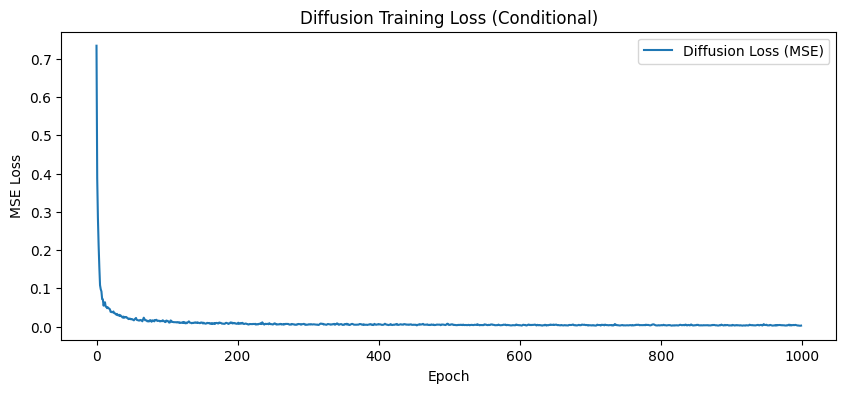

Generating conditional samples with CFG...


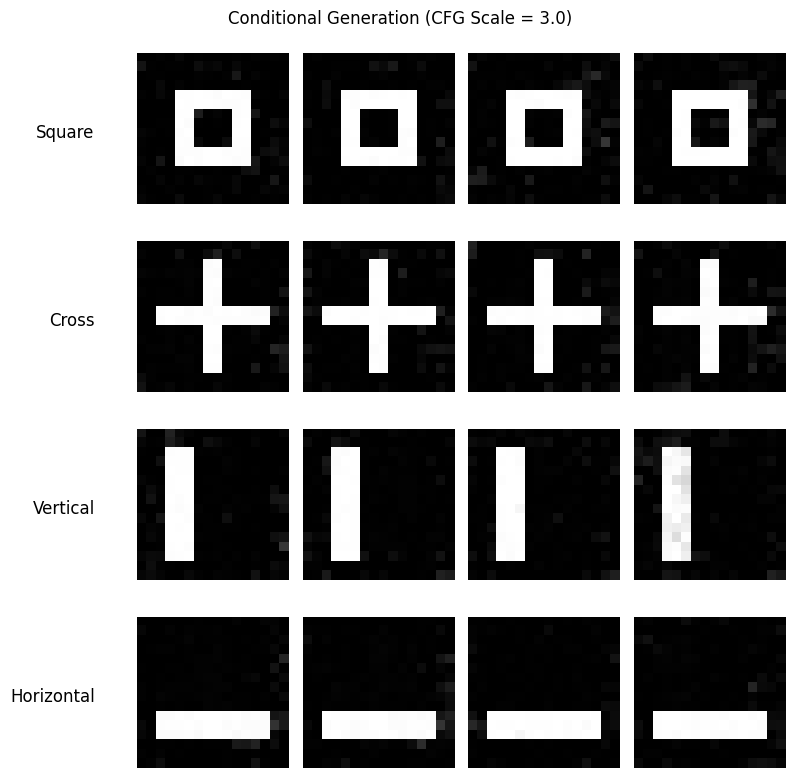

In [50]:
# ==========================================
# 7. Visualization
# ==========================================

# A. Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Diffusion Loss (MSE)")
plt.title("Diffusion Training Loss (Conditional)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# B. Generated Samples (Conditional)
model.eval()
print("Generating conditional samples with CFG...")

# We want to generate 4 examples for each of the 4 classes
# Labels: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3]
n_per_class = 4
eval_labels = torch.arange(N_CLASSES).repeat_interleave(n_per_class).to(DEVICE)

# Sample using the CFG function
gen_imgs = ddim_sample_cfg(model, eval_labels, cfg_scale=3.0, ddim_timesteps=3).cpu()

# Plotting
class_names = ["Square", "Cross", "Vertical", "Horizontal"]

plt.figure(figsize=(8, 8))
plt.suptitle(f"Conditional Generation (CFG Scale = 3.0)")

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

    # Add text label to the left of the first image in each row
    if i % 4 == 0:
        plt.text(-5, 8, class_names[i // 4], va='center', ha='right', fontsize=12)

plt.tight_layout()
plt.show()
